# Tugas Besar 2 IF3270 — CNN & RNN/LSTM Image Captioning

Notebook ini menjalankan seluruh eksperimen sesuai spesifikasi:

- §1  Setup & Shared Utilities
- §2  CNN — Training (16-variant hyperparameter sweep)
- §3  CNN — From Scratch & Evaluation
- §4  CNN — Grad-CAM [Bonus]
- §5  RNN/LSTM — Feature Extraction + Caption Preprocessing
- §6  RNN/LSTM — Training (RNN & LSTM variants)
- §7  RNN/LSTM — From Scratch & Evaluation
- §8  RNN/LSTM — Beam Search / Init-Inject [Bonus]


## §1 Setup & Shared Utilities

In [ ]:
import os
import sys
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.name and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('project root:', ROOT)

project root: c:\Users\nelson\ML-CNN-RNN


In [ ]:
DATA_DIR = ROOT / 'data'
INTEL_DIR = DATA_DIR / 'intel'
FLICKR_DIR = DATA_DIR / 'flickr8k'
FEAT_DIR = FLICKR_DIR / 'features'
CAP_DIR = FLICKR_DIR / 'captions'

MODELS_DIR = ROOT / 'models'
OUT_DIR = ROOT / 'outputs'
for p in [FEAT_DIR, CAP_DIR, MODELS_DIR / 'cnn', MODELS_DIR / 'rnn', MODELS_DIR / 'lstm', OUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

In [ ]:
from src.shared.image_utils import load_image, load_batch, extract_and_save_features
from src.shared.activations import relu, softmax, sigmoid, tanh
from src.shared.dense_layer import DenseLayer

# sanity check on the activations
x = np.array([-1.0, 0.0, 1.0, 2.0])
print('relu  :', relu(x))
print('softmax:', softmax(x))
print('sigmoid:', sigmoid(x))
print('tanh  :', tanh(x))

relu  : [0. 0. 1. 2.]
softmax: [0.0320586  0.08714432 0.23688282 0.64391426]
sigmoid: [0.26894142 0.5        0.73105858 0.88079708]
tanh  : [-0.76159416  0.          0.76159416  0.96402758]


## §2 CNN — Training (hyperparameter sweep)

Spec Bagian 3: 16 architectures = 2 (num layers) x 2 (filter combos) x 2 (kernel) x 2 (pooling).
Loss: Sparse Categorical Crossentropy, Optimizer: Adam, metric: macro F1 (custom callback).
Dataset: Intel Image Classification (6 classes, train/val/test sudah dibagi).

In [ ]:
import tensorflow as tf
from tensorflow import keras
from src.cnn.train import CNNConfig, hyperparameter_grid, train_grid, save_artefacts

IMG_SIZE = (150, 150)
BATCH = 32
EPOCHS = 15 

train_dir = INTEL_DIR / 'seg_train' / 'seg_train'
test_dir  = INTEL_DIR / 'seg_test'  / 'seg_test'

raw_train = keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH, label_mode='int',
    validation_split=0.15, subset='training', seed=42,
)
raw_val = keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH, label_mode='int',
    validation_split=0.15, subset='validation', seed=42,
)
raw_test = keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH, label_mode='int', shuffle=False,
)
class_names = raw_train.class_names
print('classes:', class_names)

normalise = keras.layers.Rescaling(1.0 / 255.0)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train.map(lambda x, y: (normalise(x), y)).prefetch(AUTOTUNE)
val_ds   = raw_val.map(lambda x, y: (normalise(x), y)).prefetch(AUTOTUNE)
test_ds  = raw_test.map(lambda x, y: (normalise(x), y)).prefetch(AUTOTUNE)

Found 14034 files belonging to 6 classes.
Using 11929 files for training.
Found 14034 files belonging to 6 classes.
Using 2105 files for validation.
Found 3000 files belonging to 6 classes.
classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [6]:
# Build the 16-variant sweep and train.
configs = hyperparameter_grid(epochs=EPOCHS, batch_size=BATCH, input_shape=IMG_SIZE + (3,), num_classes=len(class_names))
print('total CNN variants:', len(configs))
for c in configs:
    print(' -', c.variant_name())

cnn_results = train_grid(
    configs,
    train_ds=train_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    output_root=MODELS_DIR / 'cnn',
    verbose=1,
)

total CNN variants: 16
 - l2_f32-64_k3_max
 - l2_f32-64_k3_avg
 - l2_f32-64_k5_max
 - l2_f32-64_k5_avg
 - l2_f16-32_k3_max
 - l2_f16-32_k3_avg
 - l2_f16-32_k5_max
 - l2_f16-32_k5_avg
 - l4_f32-64-128-256_k3_max
 - l4_f32-64-128-256_k3_avg
 - l4_f32-64-128-256_k5_max
 - l4_f32-64-128-256_k5_avg
 - l4_f16-32-64-128_k3_max
 - l4_f16-32-64-128_k3_avg
 - l4_f16-32-64-128_k5_max
 - l4_f16-32-64-128_k5_avg
[1/16] Skipping l2_f32-64_k3_max; saved artefacts found.


c:\Users\nelson\ML-CNN-RNN\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[2/16] Skipping l2_f32-64_k3_avg; saved artefacts found.
[3/16] Skipping l2_f32-64_k5_max; saved artefacts found.
[4/16] Skipping l2_f32-64_k5_avg; saved artefacts found.
[5/16] Skipping l2_f16-32_k3_max; saved artefacts found.
[6/16] Skipping l2_f16-32_k3_avg; saved artefacts found.
[7/16] Skipping l2_f16-32_k5_max; saved artefacts found.
[8/16] Skipping l2_f16-32_k5_avg; saved artefacts found.
[9/16] Skipping l4_f32-64-128-256_k3_max; saved artefacts found.


c:\Users\nelson\ML-CNN-RNN\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[10/16] Skipping l4_f32-64-128-256_k3_avg; saved artefacts found.
[11/16] Skipping l4_f32-64-128-256_k5_max; saved artefacts found.
[12/16] Skipping l4_f32-64-128-256_k5_avg; saved artefacts found.
[13/16] Skipping l4_f16-32-64-128_k3_max; saved artefacts found.
[14/16] Skipping l4_f16-32-64-128_k3_avg; saved artefacts found.
[15/16] Skipping l4_f16-32-64-128_k5_max; saved artefacts found.
[16/16] Skipping l4_f16-32-64-128_k5_avg; saved artefacts found.


In [7]:
# Build a summary table of all variants and pick the best one for §3.
rows = []
for variant, art in cnn_results.items():
    rows.append({
        'variant': variant,
        'test_macro_f1': art['test_macro_f1'],
        'elapsed_sec': art['elapsed_seconds'],
        'num_layers': art['config']['num_conv_layers'],
        'filters': art['config']['filters_per_layer'][:art['config']['num_conv_layers']],
        'kernel': art['config']['kernel_size'],
        'pooling': art['config']['pooling_type'],
    })
rows.sort(key=lambda r: (r['test_macro_f1'] if r['test_macro_f1'] is not None else -1), reverse=True)
for r in rows:
    print(r)

best_cnn_variant = rows[0]['variant']
print('best CNN variant:', best_cnn_variant)
with open(OUT_DIR / 'cnn_sweep_results.json', 'w', encoding='utf-8') as f:
    json.dump(rows, f, indent=2)

{'variant': 'l4_f32-64-128-256_k5_max', 'test_macro_f1': 0.8569575701404606, 'elapsed_sec': 3686.245994567871, 'num_layers': 4, 'filters': [32, 64, 128, 256], 'kernel': 5, 'pooling': 'max'}
{'variant': 'l4_f32-64-128-256_k3_max', 'test_macro_f1': 0.8528396963467663, 'elapsed_sec': 1754.3369722366333, 'num_layers': 4, 'filters': [32, 64, 128, 256], 'kernel': 3, 'pooling': 'max'}
{'variant': 'l4_f16-32-64-128_k3_max', 'test_macro_f1': 0.8501190289182551, 'elapsed_sec': 714.1509511470795, 'num_layers': 4, 'filters': [16, 32, 64, 128], 'kernel': 3, 'pooling': 'max'}
{'variant': 'l4_f32-64-128-256_k3_avg', 'test_macro_f1': 0.8479696983364357, 'elapsed_sec': 1840.5515081882477, 'num_layers': 4, 'filters': [32, 64, 128, 256], 'kernel': 3, 'pooling': 'avg'}
{'variant': 'l4_f32-64-128-256_k5_avg', 'test_macro_f1': 0.8454573401530774, 'elapsed_sec': 3820.195597410202, 'num_layers': 4, 'filters': [32, 64, 128, 256], 'kernel': 5, 'pooling': 'avg'}
{'variant': 'l4_f16-32-64-128_k3_avg', 'test_macro

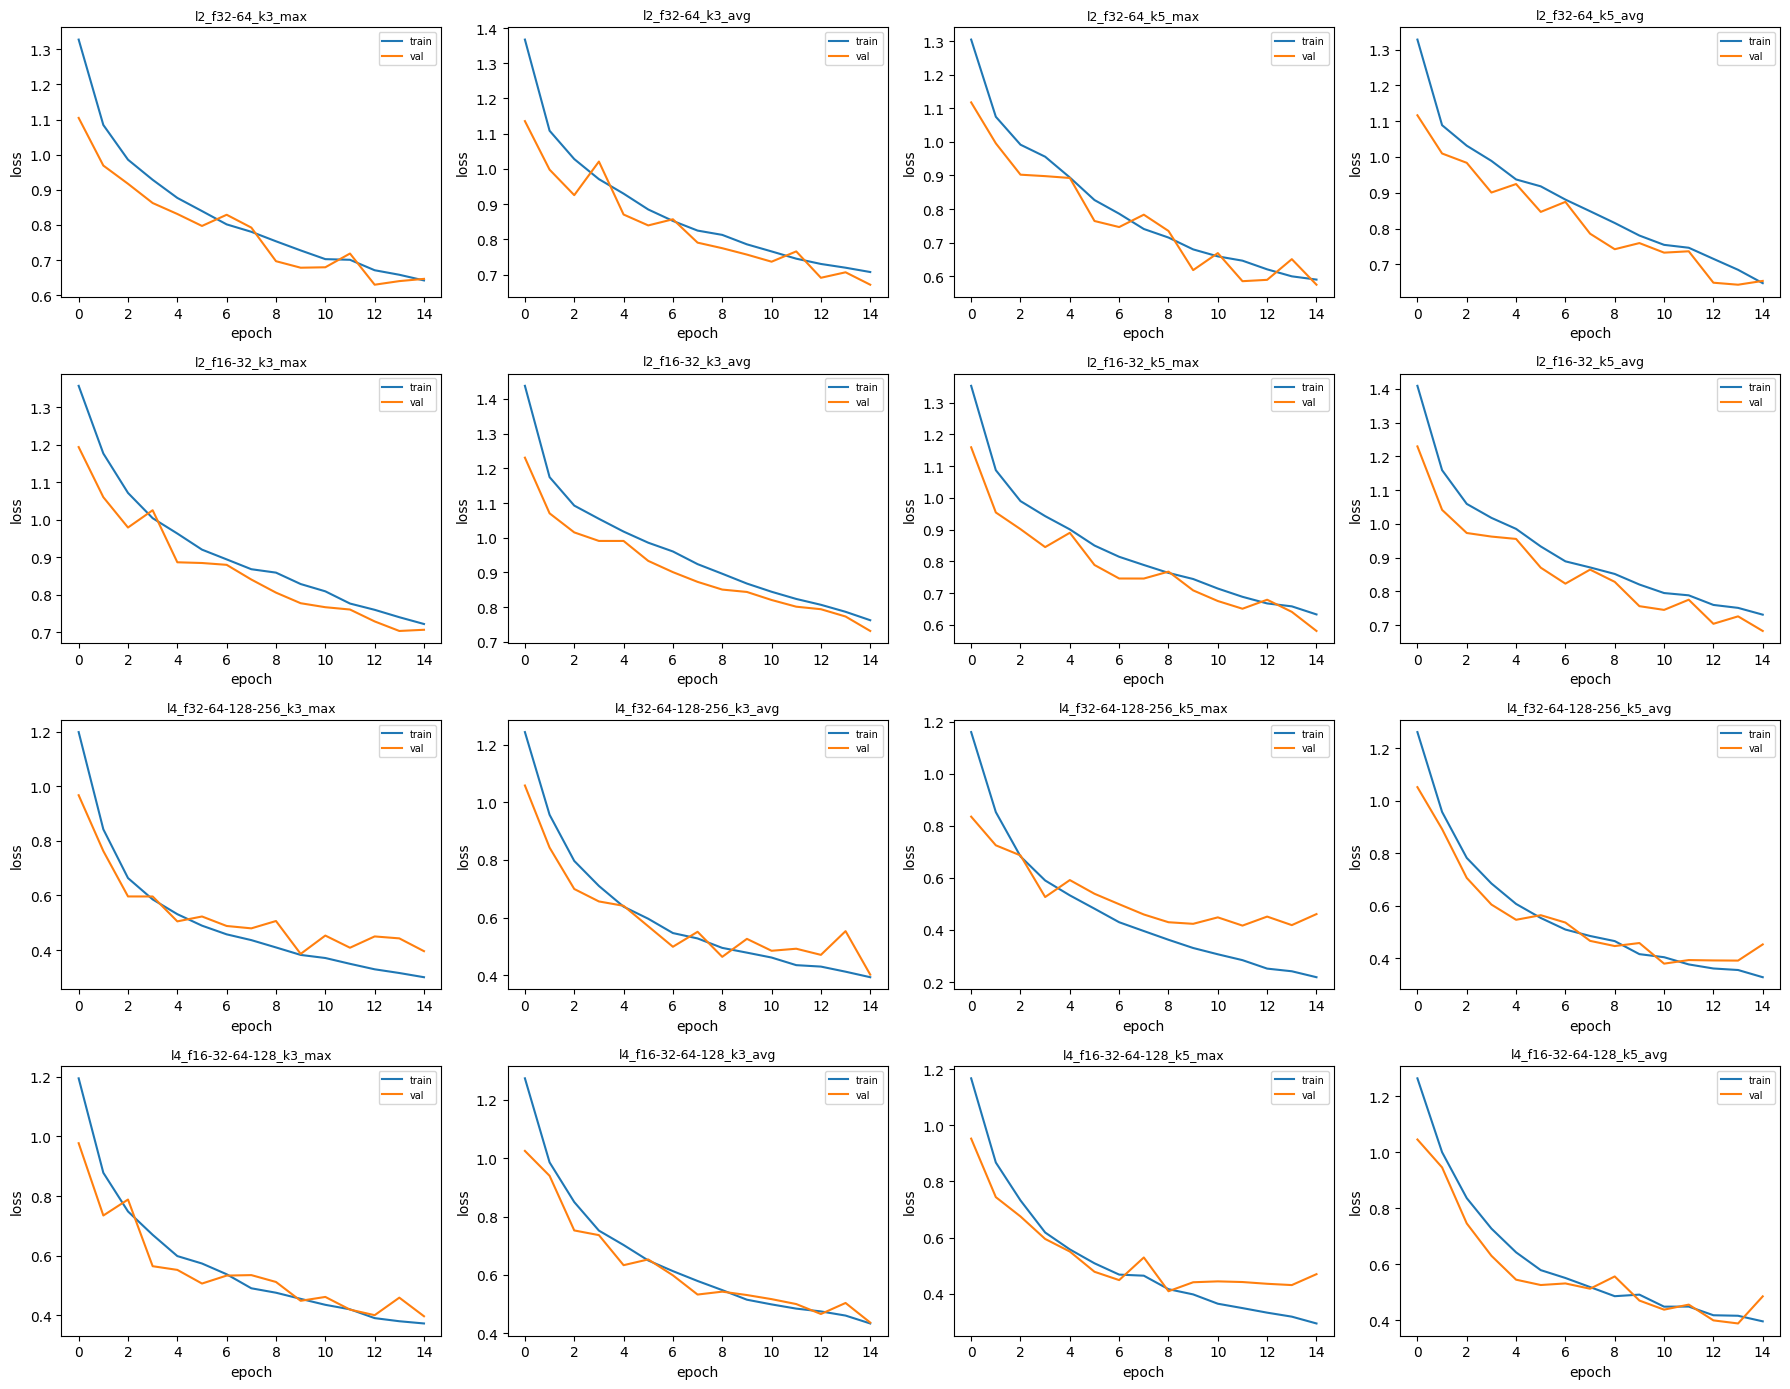

In [8]:
# Plot training / validation loss curves for each variant.
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, (variant, art) in enumerate(cnn_results.items()):
    if i >= len(axes):
        break
    h = art['history']
    ax = axes[i]
    ax.plot(h.get('loss', []), label='train')
    ax.plot(h.get('val_loss', []), label='val')
    ax.set_title(variant, fontsize=9)
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(OUT_DIR / 'cnn_loss_curves.png', dpi=120)
plt.show()

## §3 CNN — From Scratch & Evaluation

Bandingkan macro F1 Keras vs from-scratch pada test set untuk arsitektur terbaik. Lalu
ulangi dengan Conv2D diganti LocallyConnected2D (shared vs non-shared).

In [ ]:
from src.cnn.scratch_model import CNNScratchModel
from sklearn.metrics import f1_score

best_art = cnn_results[best_cnn_variant]
keras_best = best_art['model']
weights_file = MODELS_DIR / 'cnn' / (best_cnn_variant + '.weights.h5')
keras_best.load_weights(weights_file)

X_test, y_test = [], []
for xb, yb in test_ds:
    X_test.append(xb.numpy())
    y_test.append(yb.numpy())
X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)
print('test set shape:', X_test.shape, y_test.shape)

scratch_shared = CNNScratchModel.load_from_keras(keras_best)
scratch_preds = []
for i in range(X_test.shape[0]):
    logits = scratch_shared.forward(X_test[i])
    scratch_preds.append(int(np.argmax(logits)))
scratch_f1 = f1_score(y_test, scratch_preds, average='macro', zero_division=0)
print('Keras  macro F1:', best_art['test_macro_f1'])
print('Scratch macro F1:', scratch_f1)

test set shape: (3000, 150, 150, 3) (3000,)
Keras  macro F1: 0.8569575701404606
Scratch macro F1: 0.8569575701404606


In [ ]:
from tensorflow.keras import layers as kl
from src.cnn.locally_connected_keras import LocallyConnected2D

cfg = best_art['config']
inputs = keras.Input(shape=tuple(cfg['input_shape']))
x = inputs
pool_cls = kl.MaxPooling2D if cfg['pooling_type'] == 'max' else kl.AveragePooling2D
for i in range(cfg['num_conv_layers']):
    x = LocallyConnected2D(
        filters=cfg['filters_per_layer'][i],
        kernel_size=cfg['kernel_size'],
        padding='valid',  
        activation='relu',
    )(x)
    x = pool_cls(pool_size=(2, 2))(x)
x = kl.GlobalAveragePooling2D()(x)
x = kl.Dense(128, activation='relu')(x)
outputs = kl.Dense(len(class_names), activation='softmax')(x)
model_nonshared = keras.Model(inputs, outputs)
model_nonshared.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)
NONSHARED_EPOCHS = min(cfg['epochs'], 5)
history_nonshared = model_nonshared.fit(train_ds, validation_data=val_ds, epochs=NONSHARED_EPOCHS, verbose=1)

preds_ns = np.argmax(model_nonshared.predict(test_ds, verbose=0), axis=1)
f1_nonshared = f1_score(y_test, preds_ns, average='macro', zero_division=0)
n_shared = keras_best.count_params()
n_nonshared = model_nonshared.count_params()
print('shared params    :', n_shared)
print('non-shared params:', n_nonshared)
print('shared    F1 (Keras):', best_art['test_macro_f1'])
print('non-shared F1 (Keras):', f1_nonshared)

with open(OUT_DIR / 'cnn_shared_vs_nonshared.json', 'w', encoding='utf-8') as f:
    json.dump({
        'shared_f1': best_art['test_macro_f1'],
        'shared_scratch_f1': scratch_f1,
        'shared_params': int(n_shared),
        'nonshared_f1': float(f1_nonshared),
        'nonshared_params': int(n_nonshared),
    }, f, indent=2)


Epoch 1/5


## §4 CNN — Grad-CAM [Bonus]

Tampilkan intermediate feature maps + Grad-CAM heatmap untuk beberapa contoh per kelas.

last conv layer name: conv2d_27


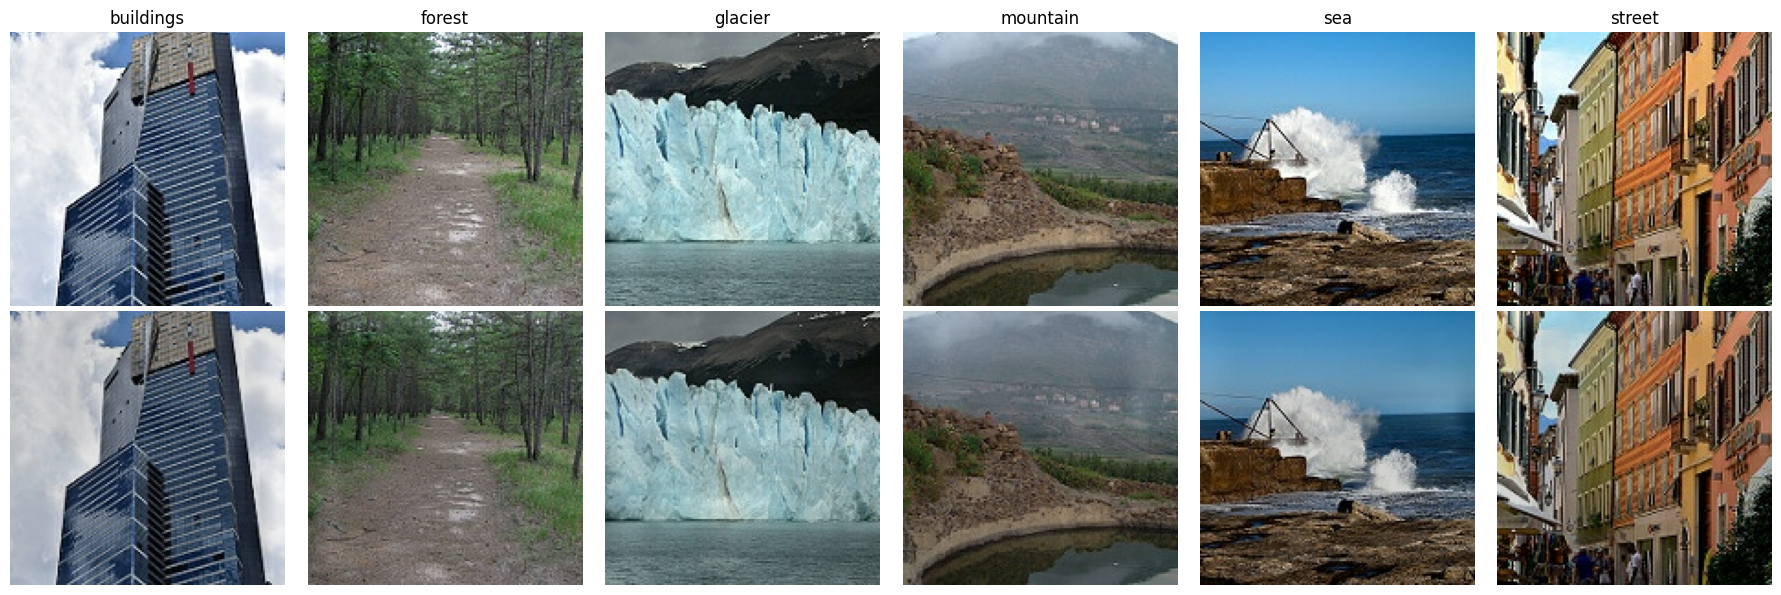

In [ ]:
from src.cnn.gradcam import get_intermediate_feature_maps, grad_cam

last_conv = None
for layer in keras_best.layers:
    if 'conv' in layer.__class__.__name__.lower():
        last_conv = layer.name
print('last conv layer name:', last_conv)

examples = {}
for i in range(X_test.shape[0]):
    c = int(y_test[i])
    if c not in examples:
        examples[c] = i
    if len(examples) == len(class_names):
        break

fig, axes = plt.subplots(2, len(class_names), figsize=(3 * len(class_names), 6))
for col, (cls_idx, img_idx) in enumerate(sorted(examples.items())):
    img = X_test[img_idx]
    heatmap = grad_cam(keras_best, img, cls_idx, last_conv)
    axes[0, col].imshow(img)
    axes[0, col].set_title(class_names[cls_idx])
    axes[0, col].axis('off')
    axes[1, col].imshow(img)
    axes[1, col].imshow(heatmap, cmap='jet', alpha=0.4)
    axes[1, col].axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'gradcam_examples.png', dpi=120)
plt.show()

## §5 RNN/LSTM — Feature Extraction + Caption Preprocessing

Ekstrak fitur CNN seluruh Flickr8k pakai InceptionV3 frozen (sekali saja). Lalu
preprocess captions: lowercase, strip punctuation, add <start>/<end>, build vocab.

In [ ]:
from src.shared.image_utils import extract_and_save_features
from src.rnn_lstm.caption_preprocessing import (
    preprocess_captions, build_vocabulary, build_index_to_word, tokenize_and_pad,
    save_vocabulary, load_vocabulary, load_flickr8k_split, prepare_dataset,
)

IMG_DIR = FLICKR_DIR / 'images'
TOKEN_FILE = FLICKR_DIR / 'Flickr8k.token.txt'
TRAIN_SPLIT = FLICKR_DIR / 'Flickr_8k.trainImages.txt'
VAL_SPLIT   = FLICKR_DIR / 'Flickr_8k.devImages.txt'
TEST_SPLIT  = FLICKR_DIR / 'Flickr_8k.testImages.txt'

image_files = sorted([p.name for p in IMG_DIR.glob('*.jpg')])
print('total Flickr8k images:', len(image_files))
image_paths = [str(IMG_DIR / name) for name in image_files]

encoder = keras.applications.InceptionV3(include_top=False, pooling='avg', weights='imagenet')
encoder.trainable = False

features = extract_and_save_features(
    image_paths,
    encoder,
    out_path=FEAT_DIR / 'features.npy',
    index_map_path=FEAT_DIR / 'index_map.json',
    skip_if_exists=True,
)
with open(FEAT_DIR / 'index_map.json') as f:
    index_map = json.load(f)
print('features shape:', features.shape)

total Flickr8k images: 8091
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


ValueError: Encoder input shape must define height and width: (None, None, None, 3)

In [ ]:
captions_by_image = preprocess_captions(TOKEN_FILE)
train_ids = load_flickr8k_split(TRAIN_SPLIT)
val_ids   = load_flickr8k_split(VAL_SPLIT)
test_ids  = load_flickr8k_split(TEST_SPLIT)
print('train/val/test image counts:', len(train_ids), len(val_ids), len(test_ids))

train_captions_flat = []
for img in train_ids:
    if img in captions_by_image:
        train_captions_flat.extend(captions_by_image[img])
word2idx = build_vocabulary(train_captions_flat, min_freq=2)
idx2word = build_index_to_word(word2idx)
print('vocab size:', len(word2idx))

save_vocabulary(word2idx, CAP_DIR / 'vocab.json')

MAX_LEN = 35
train_feats, train_in, train_tgt = prepare_dataset(
    captions_by_image, train_ids, features, index_map, word2idx, MAX_LEN
)
val_feats, val_in, val_tgt = prepare_dataset(
    captions_by_image, val_ids, features, index_map, word2idx, MAX_LEN
)
print('train:', train_feats.shape, train_in.shape, train_tgt.shape)
print('val  :', val_feats.shape, val_in.shape, val_tgt.shape)

np.save(CAP_DIR / 'sequences_train.npy', train_in)
np.save(CAP_DIR / 'sequences_val.npy', val_in)

train/val/test image counts: 6000 1000 1000
vocab size: 4447


NameError: name 'features' is not defined

## §6 RNN/LSTM — Training (RNN & LSTM variants)

Spec Bagian 3: 12 variants = 2 decoders (SimpleRNN, LSTM) x 3 layer counts x 2 hidden sizes.

In [ ]:
from src.rnn_lstm.train import hyperparameter_grid as rnn_grid, train_grid as rnn_train_grid

EPOCHS_DEC = 20
BATCH_DEC = 64

decoder_configs = rnn_grid(epochs=EPOCHS_DEC, batch_size=BATCH_DEC)
print('total decoder variants:', len(decoder_configs))
for c in decoder_configs:
    print(' -', c.variant_name())

decoder_results = rnn_train_grid(
    decoder_configs,
    train_features=train_feats,
    train_decoder_input=train_in,
    train_decoder_target=train_tgt,
    val_features=val_feats,
    val_decoder_input=val_in,
    val_decoder_target=val_tgt,
    vocab_size=len(word2idx),
    output_root=MODELS_DIR,
    verbose=1,
)

total decoder variants: 12
 - pre_inject_lstm_l1_h128_e256
 - pre_inject_lstm_l1_h512_e256
 - pre_inject_lstm_l2_h128_e256
 - pre_inject_lstm_l2_h512_e256
 - pre_inject_lstm_l3_h128_e256
 - pre_inject_lstm_l3_h512_e256
 - pre_inject_rnn_l1_h128_e256
 - pre_inject_rnn_l1_h512_e256
 - pre_inject_rnn_l2_h128_e256
 - pre_inject_rnn_l2_h512_e256
 - pre_inject_rnn_l3_h128_e256
 - pre_inject_rnn_l3_h512_e256


NameError: name 'train_feats' is not defined

NameError: name 'decoder_results' is not defined

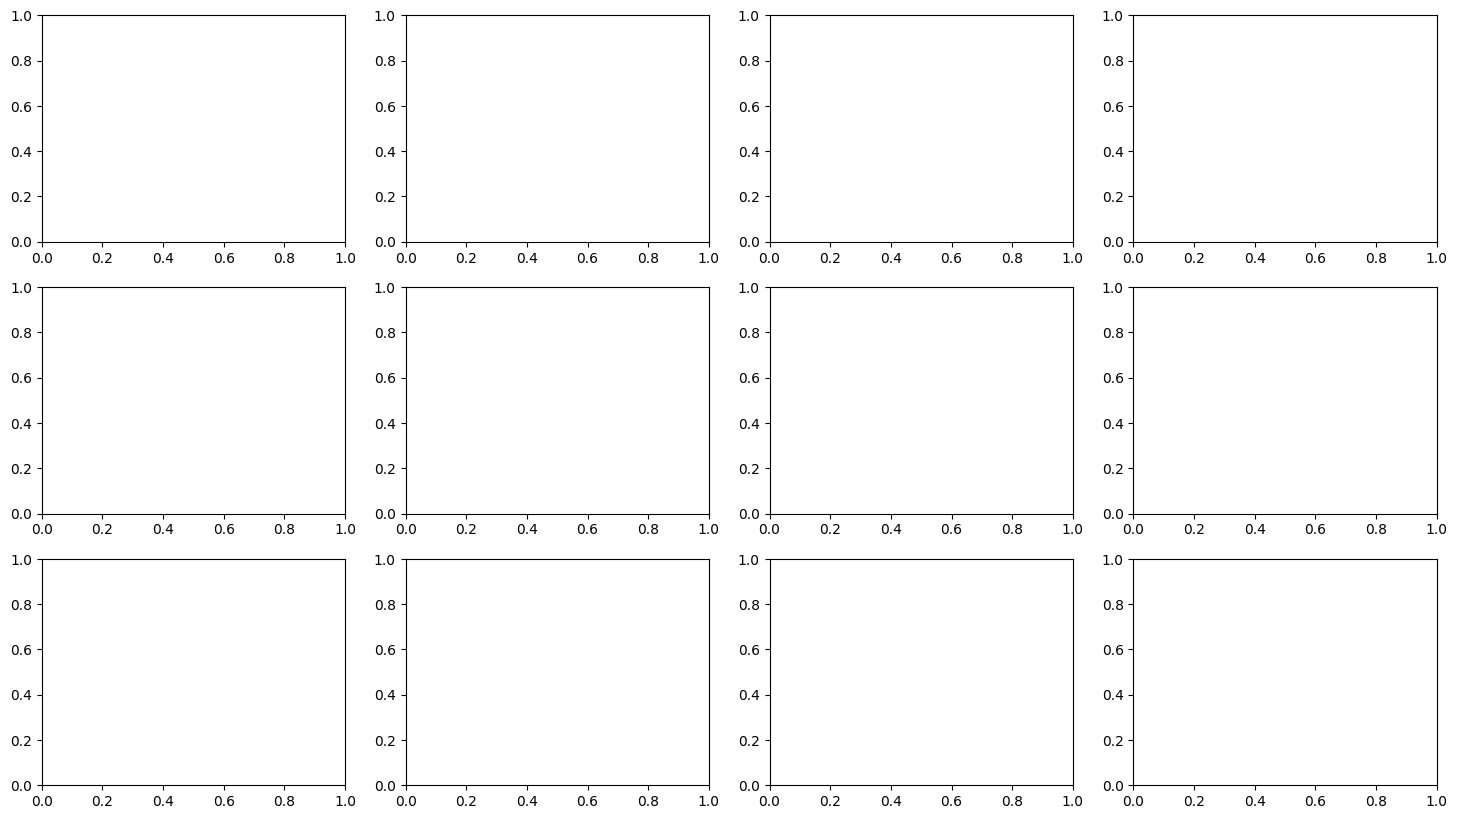

In [ ]:
# Plot training / validation loss for each decoder variant.
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()
for i, (variant, art) in enumerate(decoder_results.items()):
    h = art['history']
    ax = axes[i]
    ax.plot(h.get('loss', []), label='train')
    ax.plot(h.get('val_loss', []), label='val')
    ax.set_title(variant, fontsize=9)
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(OUT_DIR / 'rnn_lstm_loss_curves.png', dpi=120)
plt.show()

## §7 RNN/LSTM — From Scratch & Evaluation

Evaluasi semua 12 varian Keras pada test set (BLEU-4 + METEOR). Pilih best RNN dan best LSTM,
lalu bandingkan dengan implementasi from-scratch (Dev B's ImageCaptionerScratch).

In [ ]:
from src.rnn_lstm.evaluate import (
    evaluate_keras_decoder, evaluate_scratch_decoder, evaluate_beam_decoder,
    select_qualitative_examples, sweep_max_caption_length, compare_results,
)
from src.rnn_lstm.decoder import ImageCaptionerScratch

def features_for(image_ids):
    rows = [features[index_map[i]] for i in image_ids if i in index_map]
    return np.stack(rows, axis=0)

test_image_ids = [i for i in test_ids if i in index_map and i in captions_by_image]
test_feats_ev = features_for(test_image_ids)
def strip_wrap(c):
    return c.replace('<start> ', '').replace(' <end>', '').strip()
refs_by_image = {img: [strip_wrap(c) for c in captions_by_image[img]] for img in test_image_ids}

SEQ_LEN = MAX_LEN - 1  # decoder_input length used during training
all_eval_rows = []
for variant, art in decoder_results.items():
    model = art['model']
    res = evaluate_keras_decoder(
        model,
        features=test_feats_ev,
        image_ids=test_image_ids,
        references_by_image=refs_by_image,
        idx2word=idx2word,
        seq_len=SEQ_LEN,
        max_len=20,
        variant=variant,
    )
    print(variant, 'BLEU-4:', round(res.bleu4, 4), 'METEOR:', round(res.meteor, 4))
    all_eval_rows.append(res.to_dict() | {'variant': variant})

with open(OUT_DIR / 'rnn_lstm_keras_eval.json', 'w', encoding='utf-8') as f:
    json.dump(all_eval_rows, f, indent=2)

NameError: name 'index_map' is not defined

In [ ]:
# Pick the best LSTM and best RNN (highest BLEU-4) for Keras vs scratch comparison.
def best_of(rows, kind):
    candidates = [r for r in rows if kind in r['variant']]
    return sorted(candidates, key=lambda r: r['bleu4'], reverse=True)[0]

best_lstm = best_of(all_eval_rows, 'lstm')
best_rnn  = best_of(all_eval_rows, 'rnn')
print('best LSTM:', best_lstm['variant'], 'BLEU-4:', best_lstm['bleu4'])
print('best RNN :', best_rnn['variant'],  'BLEU-4:', best_rnn['bleu4'])

NameError: name 'all_eval_rows' is not defined

In [ ]:
lstm_model = decoder_results[best_lstm['variant']]['model']
rnn_model  = decoder_results[best_rnn['variant']]['model']

scratch_lstm = ImageCaptionerScratch.load_from_keras(lstm_model, word2idx=word2idx, idx2word=idx2word)
scratch_rnn  = ImageCaptionerScratch.load_from_keras(rnn_model,  word2idx=word2idx, idx2word=idx2word)

scratch_lstm_res = evaluate_scratch_decoder(
    scratch_lstm, test_feats_ev, test_image_ids, refs_by_image,
    max_len=20, variant=best_lstm['variant'] + '_scratch',
)
scratch_rnn_res = evaluate_scratch_decoder(
    scratch_rnn, test_feats_ev, test_image_ids, refs_by_image,
    max_len=20, variant=best_rnn['variant'] + '_scratch',
)

comparison = {
    'lstm_keras':   best_lstm,
    'lstm_scratch': scratch_lstm_res.to_dict(),
    'rnn_keras':    best_rnn,
    'rnn_scratch':  scratch_rnn_res.to_dict(),
}
with open(OUT_DIR / 'rnn_lstm_keras_vs_scratch.json', 'w', encoding='utf-8') as f:
    json.dump(comparison, f, indent=2)
print(json.dumps(comparison, indent=2))

NameError: name 'decoder_results' is not defined

In [ ]:
# Qualitative analysis
qual_lstm = select_qualitative_examples(scratch_lstm_res, n_high=4, n_mid=3, n_low=3)
qual_rnn  = select_qualitative_examples(scratch_rnn_res,  n_high=4, n_mid=3, n_low=3)
print('LSTM qualitative count:', len(qual_lstm))
print('RNN  qualitative count:', len(qual_rnn))

for ex in qual_lstm[:5]:
    print('---')
    print(' image:', ex['image_id'], '  BLEU-4:', round(ex['score'], 4))
    print(' pred :', ex['prediction'])
    print(' refs :', ex['references'][0])

with open(OUT_DIR / 'qualitative_examples.json', 'w', encoding='utf-8') as f:
    json.dump({'lstm': qual_lstm, 'rnn': qual_rnn}, f, indent=2)

NameError: name 'scratch_lstm_res' is not defined

In [ ]:
candidates = [
    ('lstm_keras', best_lstm['bleu4'], best_lstm['elapsed_seconds']),
    ('lstm_scratch', scratch_lstm_res.bleu4, scratch_lstm_res.elapsed_seconds),
    ('rnn_keras', best_rnn['bleu4'], best_rnn['elapsed_seconds']),
    ('rnn_scratch', scratch_rnn_res.bleu4, scratch_rnn_res.elapsed_seconds),
]
candidates.sort(key=lambda c: c[1] - 1e-6 * c[2], reverse=True)
winner = candidates[0][0]
print('overall winner:', winner)

if winner.startswith('lstm'):
    cap = scratch_lstm
    variant_tag = best_lstm['variant']
else:
    cap = scratch_rnn
    variant_tag = best_rnn['variant']

sweep_results = sweep_max_caption_length(
    eval_fn=evaluate_scratch_decoder,
    max_lens=[10, 20, 35],
    captioner=cap,
    features=test_feats_ev,
    image_ids=test_image_ids,
    references_by_image=refs_by_image,
    variant=variant_tag,
)
for r in sweep_results:
    print(r.variant, 'BLEU-4:', round(r.bleu4, 4), 'METEOR:', round(r.meteor, 4))
with open(OUT_DIR / 'max_len_sweep.json', 'w', encoding='utf-8') as f:
    json.dump([r.to_dict() for r in sweep_results], f, indent=2)

NameError: name 'best_lstm' is not defined

## §8 RNN/LSTM — Beam Search / Init-Inject [Bonus]

In [ ]:
# Beam search vs greedy, k = 3 and k = 5.
for k in [3, 5]:
    res = evaluate_beam_decoder(
        scratch_lstm,
        features=test_feats_ev,
        image_ids=test_image_ids,
        references_by_image=refs_by_image,
        max_len=20,
        beam_width=k,
        variant=best_lstm['variant'] + f'_beam{k}',
    )
    print('beam k=', k, ' BLEU-4:', round(res.bleu4, 4), ' METEOR:', round(res.meteor, 4))

NameError: name 'scratch_lstm' is not defined

In [ ]:
from src.rnn_lstm.train import DecoderConfig, train_decoder_config

init_configs = [
    DecoderConfig(rnn_type='lstm', num_layers=1, hidden_dim=256, architecture='init_inject', epochs=EPOCHS_DEC),
    DecoderConfig(rnn_type='rnn',  num_layers=1, hidden_dim=256, architecture='init_inject', epochs=EPOCHS_DEC),
]
init_results = {}
for cfg in init_configs:
    art = train_decoder_config(
        cfg,
        train_features=train_feats,
        train_decoder_input=train_in,
        train_decoder_target=train_tgt,
        val_features=val_feats,
        val_decoder_input=val_in,
        val_decoder_target=val_tgt,
        vocab_size=len(word2idx),
        output_dir=MODELS_DIR / cfg.rnn_type,
        verbose=1,
    )
    res = evaluate_keras_decoder(
        art['model'], test_feats_ev, test_image_ids, refs_by_image,
        idx2word=idx2word, seq_len=SEQ_LEN, max_len=20,
        variant=cfg.variant_name(),
    )
    init_results[cfg.variant_name()] = res.to_dict()
    print(cfg.variant_name(), 'BLEU-4:', round(res.bleu4, 4))

with open(OUT_DIR / 'init_inject_results.json', 'w', encoding='utf-8') as f:
    json.dump(init_results, f, indent=2)

NameError: name 'train_feats' is not defined

## Done